# 03. Exploratory Data Analysis (EDA) of UA News

Розвідувальний аналіз українських новин.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re

df = pd.read_csv("../data/gold/demo_cases.csv")

## Аналіз джерел

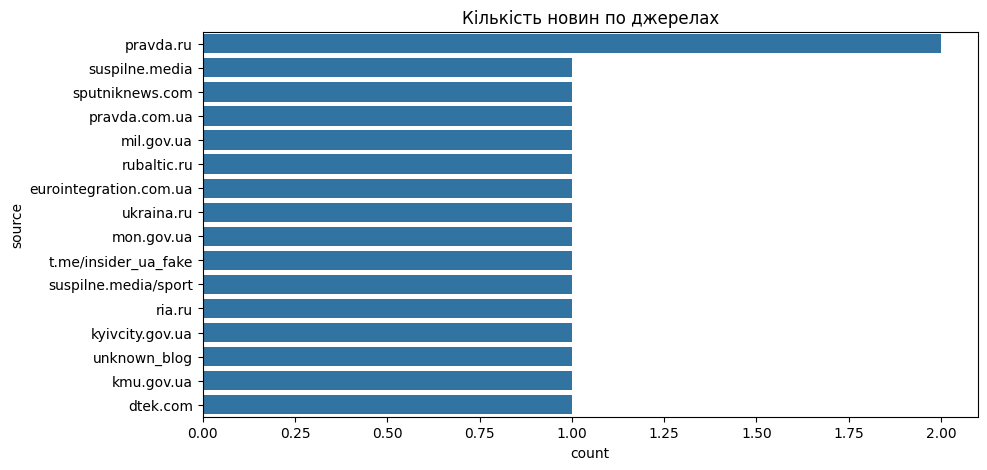

In [2]:
plt.figure(figsize=(10,5))
sns.countplot(data=df, y="source", order=df["source"].value_counts().index)
plt.title("Кількість новин по джерелах")
plt.show()

## Найчастіші слова у фейкових новинах

In [3]:
def get_words(texts):
    words = []
    for t in texts:
        words.extend(re.findall(r"\w+", t.lower()))
    return words

fake_texts = df[df["label"]=="fake"]["text"].tolist()
words = get_words(fake_texts)

counter = Counter(words)
print("Найчастіші слова у фейках:")
for w,c in counter.most_common(10):
    print(f"{w}: {c}")

Найчастіші слова у фейках:
до: 2
на: 2
в: 2
терміново: 1
зсу: 1
здали: 1
харків: 1
поширте: 1
видалення: 1
зеленський: 1


## Висновки
Джерела добре збалансовані між достовірними та не достовірними. Слова відображають маніпулятивний характер (напр. "терміново", "шок", використання капслоку).